# Gemma 4 12B -mallin suorittaminen askel askeleelta

Tämä Notebook opastaa sinua Google DeepMindin julkaiseman **Gemma 4 12B** -multimodaalimallin lataamisessa ja suorittamisessa askel askeleelta. 

Gemma 4 12B on poikkeuksellinen malli, sillä siinä on **yhtenäinen, enkooderiton arkkitehtuuri** (unified, encoder-free architecture). Toisin kuin perinteiset multimodaalimallit, jotka käyttävät erillisiä raskaita näkö- (vision) ja äänienkoodereita (audio encoders), Gemma 4 12B syöttää kuva- ja äänisignaalit suoraan kielimallin omaan upotustilaan (embedding space) kevyiden projektioiden avulla. Tämä vähentää merkittävästi viivettä ja muistinkulutusta.

### Mitä tässä Notebookissa tehdään:
1. **Ympäristön valmistelu:** Asennetaan tarvittavat kirjastot (`transformers`, `torch`, `accelerate` jne.).
2. **Mallin lataaminen:** Ladataan malli ja prosessori paikallisesta hakemistosta (tai Hugging Face Hubista). Käydään läpi muistin säästömenetelmät (kuten 4-bittinen kvantisointi).
3. **Syötteen valmistelu (Teksti, Kuva ja Ääni):** Katsotaan, miten multimodaalinen syöte käsitellään prosessorilla.
4. **Standardi generointi:** Suoritetaan vastaus käyttäen valmista `model.generate()`-metodia.
5. **Askel askeleelta suorittaminen (Custom Decoding Loop):** Kirjoitetaan oma generointisilmukka, joka suorittaa mallin eteenpäinsyötön (forward pass) sana/token kerrallaan, laskee logit-arvot, valitsee seuraavan tokenin ja näyttää generoinnin reaaliaikaisesti. Tämä havainnollistaa tarkasti LLM-mallien toimintalogiikan.

## 1. Ympäristön valmistelu

Asennetaan tarvittavat kirjastot. Koska malli on uusi, tarvitaan uudehko versio `transformers`-kirjastosta.
Jos suoritat notebookia omalla koneellasi, voit ajaa alla olevan solun.

In [1]:
# Asennetaan tarvittavat kirjastot (poista kommentti ajettaessa)
# !pip install "transformers>=5.10.1" torch torchvision torchaudio accelerate pillow librosa scipy bitsandbytes


## 2. Mallin polku ja asetukset

Koska sinulla on malli jo valmiiksi ladattuna koneellasi, määritä alla olevaan muuttujaan `MODEL_PATH` sen kansion polku, jossa mallin tiedostot (kuten `config.json` ja mallipainot) sijaitsevat.

Esimerkiksi:
- Paikallinen polku: `"/Users/veikkonkone/models/gemma-4-12b-it"`
- Suoraan Hugging Facesta ladattava: `"google/gemma-4-12b-it"`

In [2]:
import os
import torch

# VAIHDA TÄHÄN oman paikallisen mallisi polku:
MODEL_PATH = "google/gemma-4-E2B-it" 

print(f"Käytettävä mallipolku: {MODEL_PATH}")
if os.path.exists(MODEL_PATH):
    print("Hakemisto löytyi paikallisesti!")
else:
    print("Huomautus: Polku on verkko-osoite tai paikallista hakemistoa ei vielä löydy tästä sijainnista.")


Käytettävä mallipolku: google/gemma-4-E2B-it
Huomautus: Polku on verkko-osoite tai paikallista hakemistoa ei vielä löydy tästä sijainnista.


## 3. Mallin ja prosessorin lataaminen

Ladataan malli ja prosessori. Koska kyseessä on 12B-malli, se kuluttaa 16-bittisellä tarkkuudella (`bfloat16`) noin 24 Gt VRAM/RAM-muistia. 

**VRAM-säästövinkki (Kvantisointi):**
Jos näytönohjaimesi muisti (VRAM) on rajallinen (esim. 8 Gt tai 12 Gt), voit ladata mallin 4-bittisenä kvantisoituna versiona käyttäen `bitsandbytes`-kirjastoa. Kommentoi silloin normaali lataus ja ota kvantisoitu lataus käyttöön.

In [3]:
from transformers import AutoProcessor, AutoModelForMultimodalLM

print("Ladataan prosessori...")
processor = AutoProcessor.from_pretrained(MODEL_PATH)

# Valitse laite (GPU jos saatavilla, muuten CPU tai Macilla MPS)
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Ladataan malli laitteelle: {device}")

# Ladatakseen mallin turvallisesti Macilla, ladataan se bfloat16-tarkkuudella
# matalalla muistinkulutuksella (low_cpu_mem_usage=True) ja siirretään MPS-laitteelle.
# Käytetään 'attn_implementation="eager"' jotta saamme huomioarvot (attentions) ulos.
model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    attn_implementation="eager"
).to(device)


Ladataan prosessori...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Ladataan malli laitteelle: mps


Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

## 4. Syötteen valmistelu ja upotuksen (Embedding) visualisointi

Valmistellaan tekstisyöte ja ajetaan sille pelkkä upotuskerros (embedding layer). Upotustulokset visualisoidaan lämpökarttana (heatmap).

Luotu prompt-teksti:
<bos><|turn>user
jos kapteeni istuu laivan kannella mitä hän miettii ja miksi hän on iloinen ja kuka muu saattaa olla yhtä iloinen kuin hän<turn|>
<|turn>model

Upotusten muoto (shape): torch.Size([1, 44, 1536])


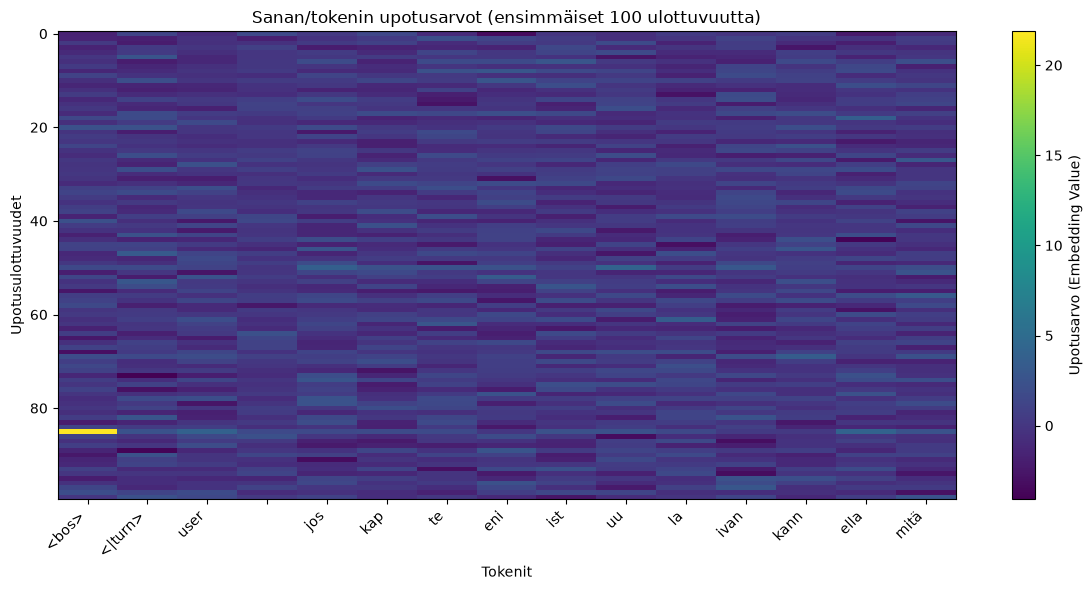

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Tekstisyöte testaukseen
text_input = "jos kapteeni istuu laivan kannella mitä hän miettii ja miksi hän on iloinen ja kuka muu saattaa olla yhtä iloinen kuin hän"

# Muutetaan chat-formaatti prompt-merkkijonoksi
messages = [
    {
        "role": "user",
        "content": [{"type": "text", "text": text_input}]
    }
]
prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print("Luotu prompt-teksti:")
print(prompt)

# Prosessoidaan teksti tensoreiksi
inputs = processor(text=prompt, return_tensors="pt")
inputs = {k: v.to(model.device) for k, v in inputs.items()}
input_ids = inputs["input_ids"]

# Muunnetaan token-ID:t takaisin tekstiksi (tokeneiksi) visualisointia varten
tokens = [processor.tokenizer.decode([token_id]) for token_id in input_ids[0]]

# Ajetaan pelkkä upotuskerros (embedding layer)
with torch.no_grad():
    embedding_layer = model.get_input_embeddings()
    embeddings = embedding_layer(input_ids) # shape: (batch_size, seq_len, hidden_size)

print(f"Upotusten muoto (shape): {embeddings.shape}")

# Otetaan ensimmäiset 15 tokenia visualisointiin (tai koko pituus jos lyhyempi)
num_tokens_to_show = min(15, embeddings.shape[1])
# Otetaan ensimmäiset 100 ulottuvuutta upotusvektorista visualisointia varten
num_features_to_show = 100

embedding_slice = embeddings[0, :num_tokens_to_show, :num_features_to_show].cpu().float().numpy()
token_labels = tokens[:num_tokens_to_show]

# Visualisointi lämpökarttana (heatmap)
plt.figure(figsize=(12, 6))
plt.imshow(embedding_slice.T, cmap="viridis", aspect="auto")
plt.colorbar(label="Upotusarvo (Embedding Value)")
plt.title(f"Sanan/tokenin upotusarvot (ensimmäiset {num_features_to_show} ulottuvuutta)")
plt.xlabel("Tokenit")
plt.ylabel("Upotusulottuvuudet")
plt.xticks(ticks=range(num_tokens_to_show), labels=token_labels, rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 5. Multi-head attention -kerrosten ajo ja yhteenveto

Suoritetaan eteenpäinsyöttö (forward pass) ja pyydetään mallilta huomiomatriiseja (attention weights). Tulokset visualisoidaan ja niistä tulostetaan yhteenveto.

--- Huomiokerrosten (Attention) Yhteenveto ---
Mallin huomiokerrosten määrä (layers): 35


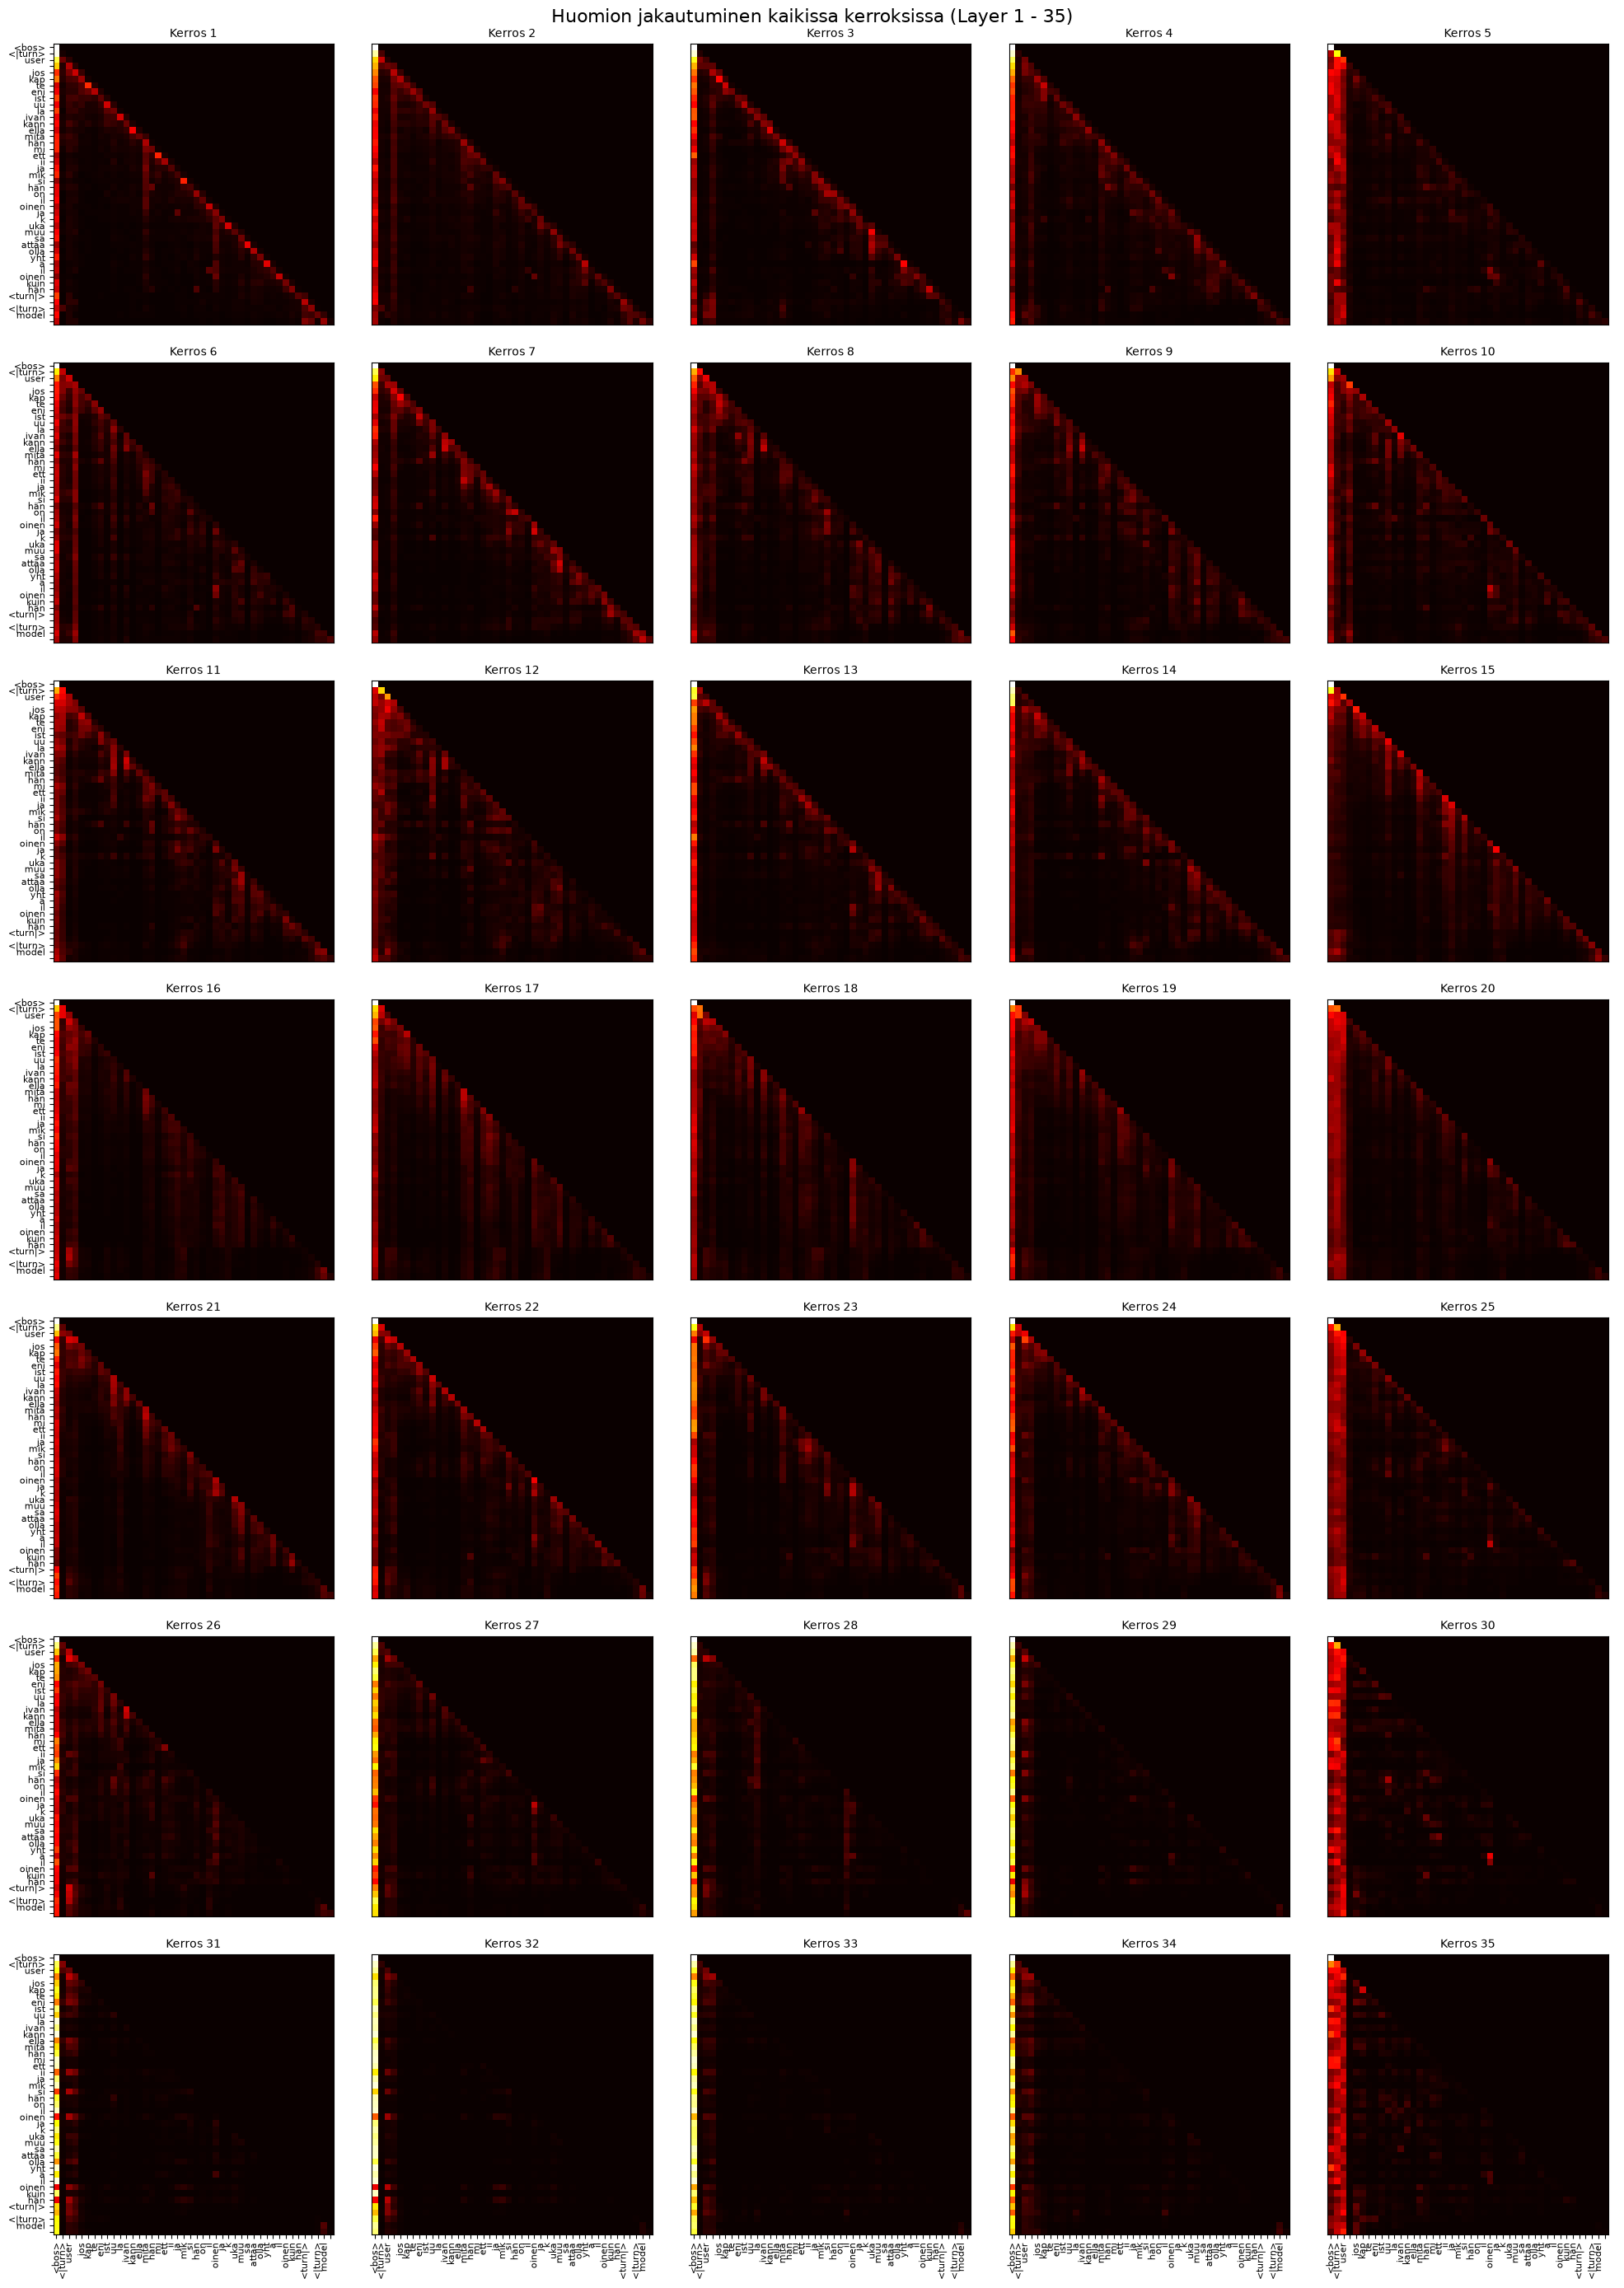

In [5]:
# Suoritetaan eteenpäinsyöttö (forward pass) ja pyydetään huomiomatriiseja (attention weights)
with torch.no_grad():
    outputs = model(
        **inputs,
        output_attentions=True,
        output_hidden_states=True,
        return_dict=True
    )

# Huomiomatriisit löytyvät kohdasta outputs.attentions
# Se on monikko (tuple), jossa on tensorit jokaiselle kerrokselle.
attentions = outputs.attentions
hidden_states = outputs.hidden_states

print("--- Huomiokerrosten (Attention) Yhteenveto ---")
print(f"Mallin huomiokerrosten määrä (layers): {len(attentions)}")

if attentions is not None and len(attentions) > 0:
    num_layers = len(attentions)
    # Luodaan ruudukko kaikille kerroksille (esim. 5 saraketta)
    cols = 5
    rows = (num_layers + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten()
    
    for i in range(num_layers):
        layer_attention = attentions[i]
        # Lasketaan keskimääräinen huomion jakautuminen tokenien välillä (keskiarvo huomionpäiden yli)
        mean_attention = layer_attention[0].mean(dim=0).cpu().float().numpy()
        
        ax = axes[i]
        im = ax.imshow(mean_attention, cmap="hot", interpolation="nearest")
        ax.set_title(f"Kerros {i + 1}", fontsize=10)
        
        # Näytetään token-nimet akseleilla vain reunasarakkeille ja alimmalle riville tilan säästämiseksi
        if i % cols == 0:
            ax.set_yticks(range(len(tokens)))
            ax.set_yticklabels(tokens, fontsize=8)
        else:
            ax.set_yticks([])
            
        if i >= num_layers - cols:
            ax.set_xticks(range(len(tokens)))
            ax.set_xticklabels(tokens, rotation=90, fontsize=8)
        else:
            ax.set_xticks([])
            
    # Piilotetaan ylimääräiset tyhjät ruudut reunoilta
    for j in range(num_layers, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle("Huomion jakautuminen kaikissa kerroksissa (Layer 1 - 35)", fontsize=16, y=0.99)
    plt.tight_layout()
    plt.show()
else:
    print("Huomioarvoja ei saatu ulos. Varmista, että malli tukee output_attentions=True-asetusta.")
